# Loading flower images dataset

In [2]:
# Load flower images
import tensorflow as tf
from tensorflow import keras
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir='.', untar=True)

In [3]:
data_dir

'./datasets/flower_photos'

In [4]:
# Set dataset path
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [5]:
list(data_dir.glob('**/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/tulips/4945315538_97bdd873c4.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/3253320570_b617f7fd4b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/483880052_19fdb26a9f.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/13910471347_30c8bf4de1_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/8520482921_21dd204ebd_n.jpg')]

In [6]:
image_count = len(list(data_dir.glob('**/*.jpg')))
print(image_count)

3670


In [7]:
roses = list(data_dir.glob('**/roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/14166797345_d2ab9da518.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4764674741_82b8f93359_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3667366832_7a8017c528_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/11944957684_2cc806276e.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/8523394349_61b31fdd8f_m.jpg')]

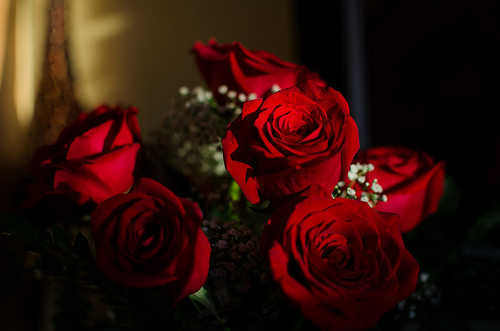

In [8]:
import PIL
PIL.Image.open(str(roses[0]))

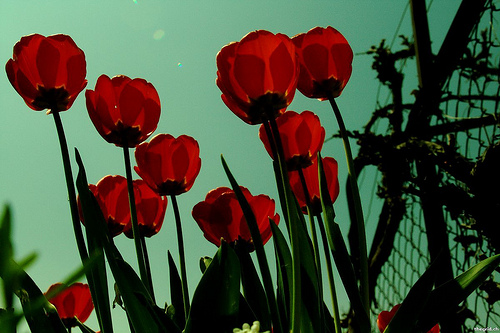

In [9]:
tulips = list(data_dir.glob('**/tulips/*'))
PIL.Image.open(str(tulips[0]))

# Converting into dataset

In [10]:
# Storing image file paths in a dict
flowers_images_dict = {
    'roses': list(data_dir.glob('**/roses/*')),
    'daisy': list(data_dir.glob('**/daisy/*')),
    'dandelion': list(data_dir.glob('**/dandelion/*')),
    'sunflowers': list(data_dir.glob('**/sunflowers/*')),
    'tulips': list(data_dir.glob('**/tulips/*')),
}

In [11]:
# Defining labels
flowers_labels_dict = {
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [14]:
flowers_images_dict['daisy'][:5]

[PosixPath('datasets/flower_photos/flower_photos/daisy/2538504987_fe524b92a8_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/2599662355_7782218c83.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/172967318_c596d082cc.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/4407065098_ef25f1ccac_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/4538877108_3c793f7987_m.jpg')]

array([[[ 95, 170, 226],
        [ 92, 166, 222],
        [ 89, 160, 217],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 94, 169, 225],
        [ 91, 165, 221],
        [ 88, 159, 216],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 93, 168, 224],
        [ 90, 164, 220],
        [ 87, 158, 215],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[  0,   3,   7],
        [  1,   4,   8],
        [  1,   4,   9],
        ...,
        [  9,  10,   8],
        [  9,  10,   6],
        [  9,  10,   6]],

       [[  0,   3,   7],
        [  1,   4,   8],
        [  1,   4,   8],
        ...,
        [  9,  10,   8],
        [  9,  10,   6],
        [  9,  10,   6]],

       [[  0,   3,   7],
        [  1,   4,   8],
        [  1,   4,   8],
        ...,
        [  9,  10,   8],
        [  9,  10,   6],
        [  9,  10,   6]]], dtype=uint8)
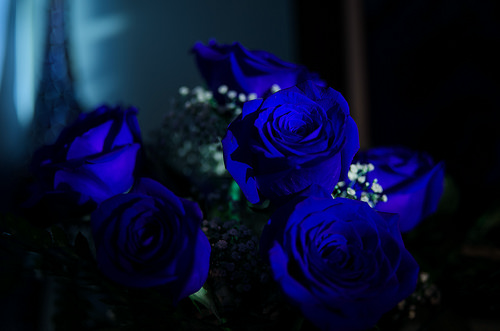

In [12]:
# Array representation of image
import cv2
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img

In [13]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(331, 500, 3)

In [14]:
# Defining X, such that X contains array representation of image and Y contains the image label
X, y = [], []

for flower_name, images in flowers_images_dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resized_img = cv2.resize(img,(180,180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])

In [15]:
# Converting into numpy arrays
import numpy as np
X = np.array(X)
y = np.array(y)

In [16]:
# Scaling
X = X/255

# Building CNN model without data augumentation

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

with tf.device('/GPU:0'):
  model = Sequential([
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),

      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(5)
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

  model.fit(X_train, y_train, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3457 - loss: 1.6213
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5739 - loss: 1.0746
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6621 - loss: 0.8936
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7431 - loss: 0.7153
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8108 - loss: 0.5328
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8736 - loss: 0.3536
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9287 - loss: 0.2342
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9722 - loss: 0.1101
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9839 - loss: 0.0626
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9839 - loss: 0.0543


In [20]:
model.evaluate(X_test, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6596 - loss: 1.5316


[1.6506016254425049, 0.6383442282676697]

Here, train accuracy is very high, but test accuracy is low

# Building CNN model with data augumentation

In [18]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

with tf.device('/GPU:0'):
  model = Sequential([
      data_augmentation,
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),

      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(5)
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

  model.fit(X_train, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3032 - loss: 1.5797
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5385 - loss: 1.1103
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6333 - loss: 0.9632
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6735 - loss: 0.8443
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6697 - loss: 0.8354
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6888 - loss: 0.7926
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7297 - loss: 0.7098
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7407 - loss: 0.6903
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7532 - loss: 0.6451
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7627 - loss: 0.6439
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7474 - loss: 0.6348
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy:

In [21]:
model.evaluate(X_test, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7417 - loss: 1.0101


[1.0396162271499634, 0.7211328744888306]